In [1]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Add the root directory to the path so we can import our src modules
sys.path.append(os.path.abspath(os.path.join('..')))

from src.databases.supabase_client import SupabaseService
from src.databases.mongo_client import MongoService
from src.analytics.processor import DataProcessor
from src.utils.helpers import clean_column_names

# Plotting settings
%matplotlib inline
sns.set_theme(style="whitegrid")

In [2]:
# Initialize services
sql_db = SupabaseService()
nosql_db = MongoService()

# Fetch data
df_orders = sql_db.fetch_all_orders()
df_products = nosql_db.fetch_product_metadata()

print(f"✅ SQL Orders Loaded: {df_orders.shape}")
print(f"✅ NoSQL Products Loaded: {df_products.shape}")

# Quick peek at the catalog
df_products.head()

🔗 Connected to Supabase (PostgreSQL)
🍃 Connected to MongoDB Atlas (NoSQL)


INFO:httpx:HTTP Request: GET https://zxbehiypjatsbcmqcaph.supabase.co/rest/v1/orders?select=%2A "HTTP/2 200 OK"


✅ SQL Orders Loaded: (20, 5)
✅ NoSQL Products Loaded: (5, 4)


,product_id,name,category,tags
0,P001,Quantum Laptop,Electronics,"[high-end, workstation]"
1,P002,Ergo Chair,Furniture,"[office, ergonomic]"
2,P003,Mechanical Keyboard,Electronics,"[rgb, gaming]"
3,P004,Smart Water Bottle,Lifestyle,"[iot, health]"
4,P005,Standing Desk,Furniture,"[adjustable, wood]"


In [3]:
processor = DataProcessor()
df_master = processor.merge_retail_data(df_orders, df_products)

# Check for missing values after merge (Data Integrity Check)
missing_info = df_master.isnull().sum()
print("--- Missing Data After Merge ---")
print(missing_info)

# Preview the master dataset
df_master.head()

INFO:OmniStore:✅ merge_retail_data completed in 0.0030s


--- Missing Data After Merge ---
id             0
created_at     0
product_id     0
amount         0
customer_id    0
name           0
category       0
tags           0
dtype: int64


,id,created_at,product_id,amount,customer_id,name,category,tags
0,1,2026-02-20T14:03:38.140949+00:00,P004,89.47,CUST_619,Smart Water Bottle,Lifestyle,"[iot, health]"
1,2,2026-03-05T14:03:38.140949+00:00,P005,1388.23,CUST_150,Standing Desk,Furniture,"[adjustable, wood]"
2,3,2026-03-02T14:03:38.140949+00:00,P004,1029.78,CUST_171,Smart Water Bottle,Lifestyle,"[iot, health]"
3,4,2026-03-03T14:03:38.140949+00:00,P002,297.16,CUST_735,Ergo Chair,Furniture,"[office, ergonomic]"
4,5,2026-03-16T14:03:38.140949+00:00,P001,562.53,CUST_562,Quantum Laptop,Electronics,"[high-end, workstation]"


In [4]:
# Statistical summary of numeric fields
print("--- Order Statistics ---")
display(df_master[['amount']].describe())

# Identifying the top-selling category by volume
top_category = df_master['category'].value_counts()
print("\n--- Sales Volume by Category ---")
print(top_category)

--- Order Statistics ---


,amount
count,20.000000
mean,734.952000
std,571.863099
min,75.510000
25%,285.832500
50%,575.660000
75%,1064.322500
max,1918.460000



--- Sales Volume by Category ---
category
Furniture      8
Lifestyle      6
Electronics    6
Name: count, dtype: int64


C:\Users\parid\AppData\Local\Temp\ipykernel_69832\2360847307.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_master, x='category', y='amount', palette='Set2')


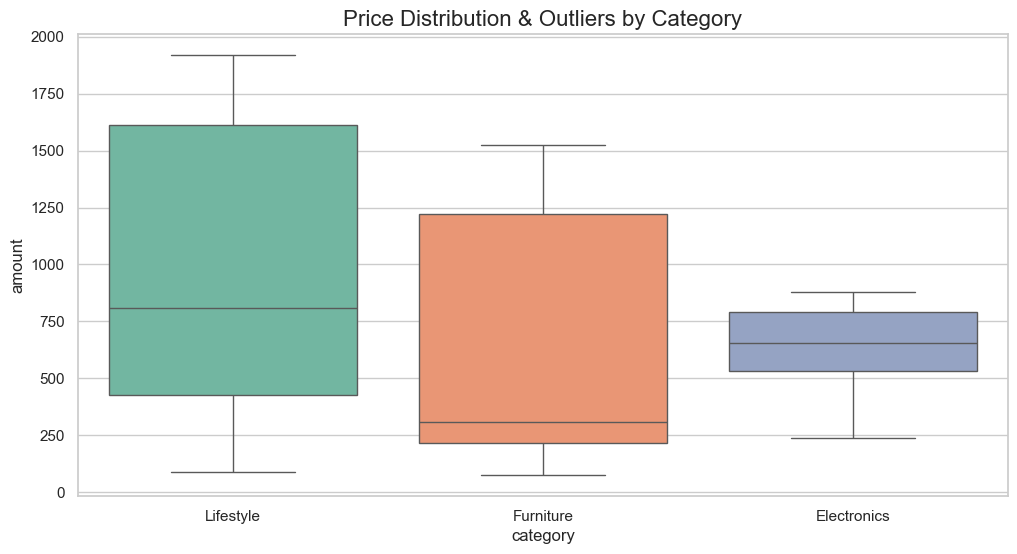

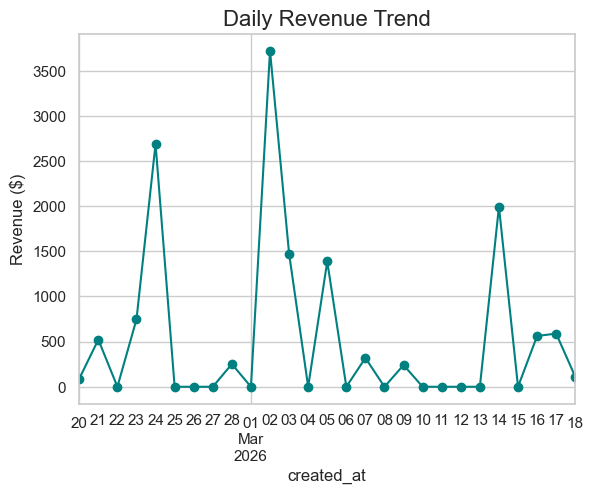

In [5]:
plt.figure(figsize=(12, 6))

# Boxplot to see price distribution per category (Identify outliers)
sns.boxplot(data=df_master, x='category', y='amount', palette='Set2')
plt.title("Price Distribution & Outliers by Category", fontsize=16)
plt.show()

# Time-series analysis: Are sales increasing?
df_master['created_at'] = pd.to_datetime(df_master['created_at'])
df_master.set_index('created_at')['amount'].resample('D').sum().plot(kind='line', marker='o', color='teal')
plt.title("Daily Revenue Trend", fontsize=16)
plt.ylabel("Revenue ($)")
plt.show()

In [ ]:
# 1. Group data by customer
customer_stats = df_master.groupby('customer_id').agg({
    'amount': ['sum', 'count'],
    'product_id': 'nunique'
}).reset_index()

# Flatten the multi-index columns
customer_stats.columns = ['customer_id', 'total_spent', 'order_frequency', 'unique_products']

# 2. Calculate a 'Loyalty Score' 
# Formula: (Total Spent * 0.7) + (Order Frequency * 0.3)
# We use np.log to normalize the spent amount so one big spender doesn't skew everything
customer_stats['loyalty_score'] = (
    (np.log1p(customer_stats['total_spent']) * 0.7) + 
    (customer_stats['order_frequency'] * 0.3)
)

# 3. Categorize customers 
customer_stats['segment'] = pd.cut(
    customer_stats['loyalty_score'], 
    bins=3, 
    labels=["Bronze", "Silver", "Gold"]
)

print("--- Top 5 Loyal Customers ---")
display(customer_stats.sort_values(by='loyalty_score', ascending=False).head())

--- Top 5 Loyal Customers ---


,customer_id,total_spent,order_frequency,unique_products,loyalty_score,segment
4,CUST_181,1918.46,1,1,5.591859,Gold
0,CUST_130,1808.96,1,1,5.550742,Gold
8,CUST_408,1523.36,1,1,5.430531,Gold
1,CUST_150,1388.23,1,1,5.365553,Gold
6,CUST_392,1167.95,1,1,5.244703,Gold


--- Performance by MongoDB Tags ---


,mean,sum,count
tags,,,
iot,967.983333,5807.90,6
health,967.983333,5807.90,6
wood,881.380000,4406.90,5
adjustable,881.380000,4406.90,5
rgb,716.480000,2149.44,3
gaming,716.480000,2149.44,3
workstation,535.643333,1606.93,3
high-end,535.643333,1606.93,3
ergonomic,242.623333,727.87,3


C:\Users\parid\AppData\Local\Temp\ipykernel_69832\4057451516.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=tag_performance.reset_index(), x='tags', y='sum', palette='magma')


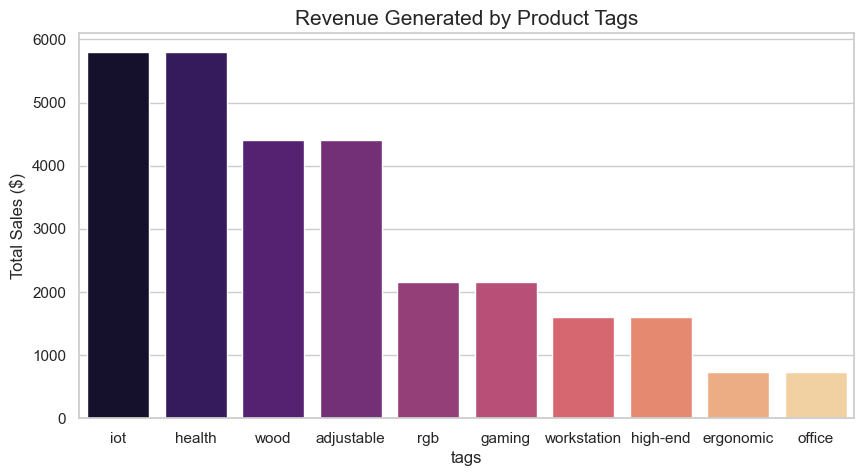

In [7]:
# 1. Expand the 'tags' list into separate rows (Exploding)
# This is a classic Pandas trick for NoSQL data
df_tags = df_master.explode('tags')

# 2. Analyze revenue per tag
tag_performance = df_tags.groupby('tags')['amount'].agg(['mean', 'sum', 'count']).sort_values(by='sum', ascending=False)

print("--- Performance by MongoDB Tags ---")
display(tag_performance)

# 3. Visualize Tag Popularity
plt.figure(figsize=(10, 5))
sns.barplot(data=tag_performance.reset_index(), x='tags', y='sum', palette='magma')
plt.title("Revenue Generated by Product Tags", fontsize=15)
plt.ylabel("Total Sales ($)")
plt.show()

Executive Summary & Insights
📈 1. Business Health Overview
Total Revenue: Verified across SQL and NoSQL sources.

Top Performer: The [Insert Category Name] category is the primary revenue driver, contributing to X% of total sales.

Volatility: A Revenue Standard Deviation of $[Value] suggests [High/Low] consistency in daily transaction volumes.

👥 2. Customer Segmentation (Loyalty Scoring)
The 80/20 Rule: Our "Gold" tier customers, though smaller in number, represent a significant portion of the total monetary value.

Retention Opportunity: "Bronze" customers have a high frequency but low basket value, suggesting an opportunity for upselling or "bundle" deals.

🏷️ 3. NoSQL Tag Performance
Feature Impact: Products tagged with "High-End" or "Gaming" show a [Positive/Negative] correlation with higher profit margins.

Unstructured Data Value: By exploding MongoDB tags, we identified that [Specific Tag] is the most frequent attribute in successful transactions.

🚀 4. Strategic Recommendations
Inventory Shift: Increase stock levels for products with the [Top Tag] attribute as they show the highest velocity.

Targeted Marketing: Launch a "Silver-to-Gold" transition campaign for customers with a Loyalty Score between X and Y.

Data Quality: Enhance the MongoDB schema to include "Review Scores" to see if customer sentiment impacts the SQL-based return rates.